Counting real occurrences...
Unique sequences: 969879
Total regions: 11159552
Hashing unique sequences...
Unique FASTA entries: 969879
Mapping sequences to clusters...
Mapped sequences: 969879
Reconstructing cluster weights...
Clusters: 18408
Total hits recovered: 11159552

Largest cluster: 6840371
Top10 fraction: 0.7953510140908883


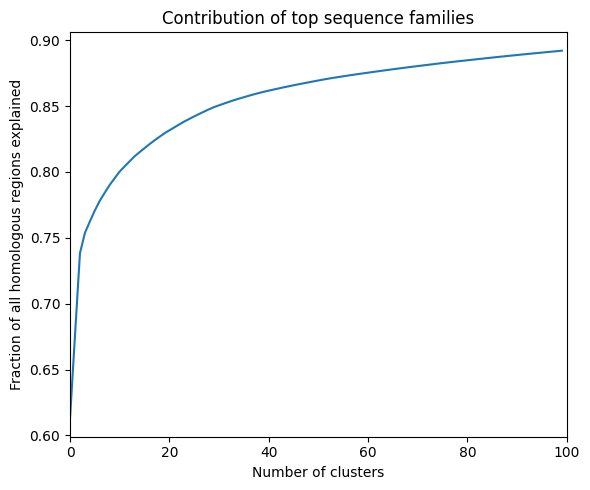

,cluster,hits
0,0,6840371
1,12,703714
2,2,696051
3,5,171500
4,26,97403
5,55,92962
6,39,82105
7,32,68872
8,20,65540
9,18,57243


In [12]:
from Bio import SeqIO
from collections import defaultdict
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ALL_FASTA = "ultra_regions.fasta"
UNIQUE_FASTA = "ultra_unique2.fasta"
CLSTR = "clusters_99_2.fasta.clstr"

# --------------------------------------------------
# 1. COUNT REAL OCCURRENCES OF EACH SEQUENCE
# --------------------------------------------------

print("Counting real occurrences...")

seq_counts = defaultdict(int)

for record in SeqIO.parse(ALL_FASTA, "fasta"):
    seq = str(record.seq).upper()
    h = hashlib.md5(seq.encode()).hexdigest()
    seq_counts[h] += 1

total_regions = sum(seq_counts.values())

print("Unique sequences:", len(seq_counts))
print("Total regions:", total_regions)

# --------------------------------------------------
# 2. HASH UNIQUE SEQUENCES (ORDER MATTERS)
# --------------------------------------------------

print("Hashing unique sequences...")

unique_hashes = []

for record in SeqIO.parse(UNIQUE_FASTA, "fasta"):
    seq = str(record.seq).upper()
    h = hashlib.md5(seq.encode()).hexdigest()
    unique_hashes.append(h)

print("Unique FASTA entries:", len(unique_hashes))

# --------------------------------------------------
# 3. MAP UNIQUE SEQUENCES TO CLUSTERS USING .CLSTR
# --------------------------------------------------

print("Mapping sequences to clusters...")

hash_to_cluster = {}

idx = 0
cluster = None

with open(CLSTR) as f:

    for line in f:

        if line.startswith(">Cluster"):
            cluster = int(line.split()[1])
            continue

        if idx >= len(unique_hashes):
            break

        h = unique_hashes[idx]
        hash_to_cluster[h] = cluster

        idx += 1

print("Mapped sequences:", len(hash_to_cluster))

# --------------------------------------------------
# 4. RECONSTRUCT REAL CLUSTER WEIGHTS
# --------------------------------------------------

print("Reconstructing cluster weights...")

cluster_hits = defaultdict(int)

for h, count in seq_counts.items():

    cluster = hash_to_cluster.get(h)

    if cluster is not None:
        cluster_hits[cluster] += count

# --------------------------------------------------
# 5. BUILD FINAL TABLE
# --------------------------------------------------

df = pd.DataFrame({
    "cluster": list(cluster_hits.keys()),
    "hits": list(cluster_hits.values())
})

df = df.sort_values("hits", ascending=False).reset_index(drop=True)

print("Clusters:", len(df))
print("Total hits recovered:", df["hits"].sum())

# --------------------------------------------------
# 6. KEY STATISTICS
# --------------------------------------------------

largest = df.iloc[0]["hits"]
top10_fraction = df.head(10)["hits"].sum() / total_regions

print("\nLargest cluster:", largest)
print("Top10 fraction:", top10_fraction)

# --------------------------------------------------
# 7. CUMULATIVE CONTRIBUTION PLOT
# --------------------------------------------------

sizes = np.sort(df["hits"])[::-1]
cum = np.cumsum(sizes) / sizes.sum()

plt.figure(figsize=(6,5))
plt.plot(cum[:100])
plt.xlabel("Number of clusters")
plt.ylabel("Fraction of all homologous regions explained")
plt.title("Contribution of top sequence families")
plt.xlim(0,100)
plt.tight_layout()
plt.show()

df.head(20)

In [13]:
from Bio import SeqIO

REP_FASTA = "clusters_99_2.fasta"

top10 = set(df.head(10)["cluster"])

records = []

for i, record in enumerate(SeqIO.parse(REP_FASTA, "fasta")):

    if i in top10:

        record.id = f"cluster_{i}|hits={df.loc[df.cluster==i,'hits'].values[0]}"
        record.description = ""

        records.append(record)

SeqIO.write(records, "top10_clusters.fasta", "fasta")

print("Top10 sequences written:", len(records))

Top10 sequences written: 10
